In [1]:
import numpy as np 
import scipy
import h5py
import matplotlib.pyplot as plt
import pandas as pd

from netneurotools.networks import struct_consensus, binarize_network

In [2]:
matlab_conns_path = "/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/data/raw/lexis_data/connectomes.mat"
age_path = "/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/data/raw/lexis_data/age.mat"
ids_path = "/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/data/raw/lexis_data/ids.csv"

In [3]:
conns_mat = h5py.File(matlab_conns_path)
age_mat = h5py.File(age_path)
ids_df = pd.read_csv(ids_path)

In [4]:
ids_df

,HCD0001305
0,HCD0008117
1,HCD0021614
2,HCD0022919
3,HCD0026119
4,HCD0029630
...,...
2413,HCA9947411
2414,HCA9953406
2415,HCA9956008
2416,HCA9986825


In [5]:
# Get all row indices of the rows that do not start with "HC"
non_hc_indices = ids_df[~ids_df['HCD0001305'].str.startswith('HC')].index
non_hc_indices.tolist()

[635,
 636,
 637,
 638,
 639,
 640,
 641,
 642,
 643,
 644,
 645,
 646,
 647,
 648,
 649,
 650,
 651,
 652,
 653,
 654,
 655,
 656,
 657,
 658,
 659,
 660,
 661,
 662,
 663,
 664,
 665,
 666,
 667,
 668,
 669,
 670,
 671,
 672,
 673,
 674,
 675,
 676,
 677,
 678,
 679,
 680,
 681,
 682,
 683,
 684,
 685,
 686,
 687,
 688,
 689,
 690,
 691,
 692,
 693,
 694,
 695,
 696,
 697,
 698,
 699,
 700,
 701,
 702,
 703,
 704,
 705,
 706,
 707,
 708,
 709,
 710,
 711,
 712,
 713,
 714,
 715,
 716,
 717,
 718,
 719,
 720,
 721,
 722,
 723,
 724,
 725,
 726,
 727,
 728,
 729,
 730,
 731,
 732,
 733,
 734,
 735,
 736,
 737,
 738,
 739,
 740,
 741,
 742,
 743,
 744,
 745,
 746,
 747,
 748,
 749,
 750,
 751,
 752,
 753,
 754,
 755,
 756,
 757,
 758,
 759,
 760,
 761,
 762,
 763,
 764,
 765,
 766,
 767,
 768,
 769,
 770,
 771,
 772,
 773,
 774,
 775,
 776,
 777,
 778,
 779,
 780,
 781,
 782,
 783,
 784,
 785,
 786,
 787,
 788,
 789,
 790,
 791,
 792,
 793,
 794,
 795,
 796,
 797,
 798,
 799,
 800,
 801

In [6]:
conns_array = np.array(conns_mat['connectomes']).T
conns_array_young_adults = conns_array[non_hc_indices, :, :]
conns_array.shape, conns_array_young_adults.shape

((2419, 100, 100), (1065, 100, 100))

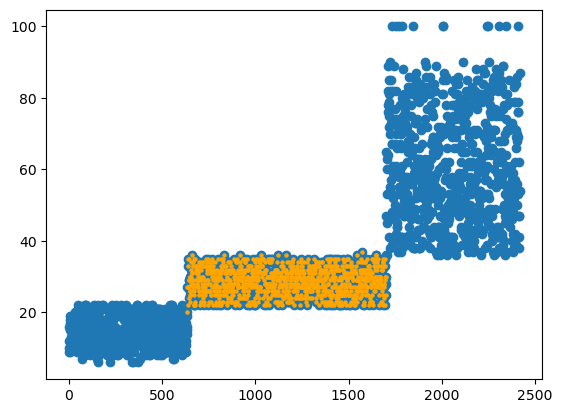

In [7]:
ages = np.array(age_mat["age"])[0] # .keys()
plt.scatter(np.arange(len(ages)), ages, label='All Participants')
plt.scatter(non_hc_indices, ages[non_hc_indices], color='orange', s=5, label='Young Adults (Non-HC)')

In [8]:
min(ages[non_hc_indices]), max(ages[non_hc_indices])

(np.float64(20.0), np.float64(37.0))

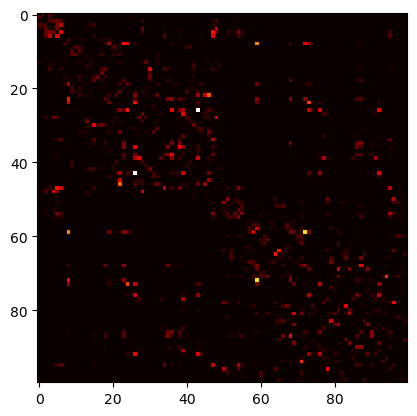

In [20]:
plt.imshow(conns_array[0], cmap='hot', interpolation='nearest')

In [21]:
distance_path = "/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/data/preprocessed/lexis_data/02_distance_matrices/distance_matrix_100.npy"
d = np.load(distance_path)
d.shape

(100, 100)

In [22]:
hemiid = [0]*50 + [1]*50  # assuming 100 regions, first 50 left, next 50 right
hemiid = np.array(hemiid).reshape(-1,1)

# Only use young adults

In [23]:
conns_array_young_adults.shape

(1065, 100, 100)

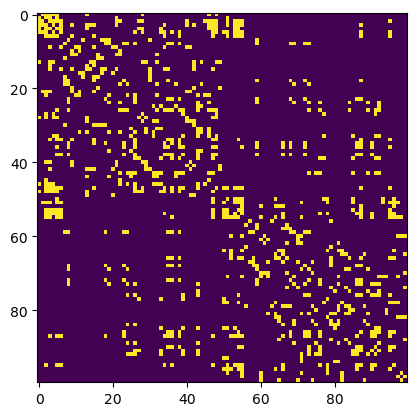

In [11]:
consensus_non_thres = struct_consensus(conns_array_young_adults.T, d, hemiid=hemiid, weighted=True) 
consensus = binarize_network(consensus_non_thres, retain=10).reshape(-1,100,100)
plt.imshow(consensus[0]) # , cmap='gray', interpolation='nearest')

In [26]:
conns_young_adults_binarized = [] 

for A in conns_array_young_adults: 
    conns_young_adults_binarized.append(binarize_network(A, retain=10)) # .reshape(-1,100,100))
    
conns_young_adults_binarized = np.array(conns_young_adults_binarized)
conns_young_adults_binarized.shape

(1065, 100, 100)

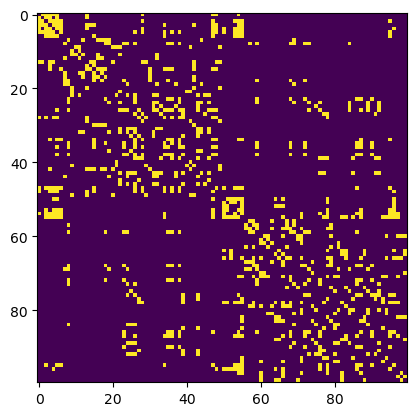

In [27]:
plt.imshow(conns_young_adults_binarized[0])

In [30]:
base_path = "/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/data/preprocessed/lexis_data/01_connectomes/"
save_path = base_path + "00_connectomes_density10.npy" # i.e. consensus
np.save(save_path, consensus)
save_path = base_path + "00_individual_connectomes_bin.npy"
np.save(save_path, conns_young_adults_binarized)